# 03 — Junior Pathway Analysis

## Overview
This notebook analyses player performance across three distinct career stages,
directly mapping to the ITF's requirement of **"reviewing performance data
relating to junior pathway training and competition testing."**

The central question is: **how does performance, improvement rate and
consistency differ across career stages — and what predicts a successful
transition from junior to professional tennis?**

## Career stage definitions

| Stage | Age | Description |
|---|---|---|
| Junior (U18) | ≤ 18 | Official ITF junior category |
| Next Gen (U19–21) | 19–21 | Transition years — establishing on the professional tour |
| Senior (21+) | > 21 | Established professional players — benchmark group |

## Methodology
Each match is classified based on the player's **actual age at the time
of the match** rather than a fixed label per player. This ensures that
a player who was 19 in 2022 and 22 in 2024 contributes to both the
Next Gen and Senior groups — their performance is analysed in the correct
developmental context for each match.

## Sample sizes
Sample sizes for each career stage will be calculated and reported in
the analysis below before drawing any conclusions.

## Analytical dimensions
1. Win rate — player-level averages to avoid match volume bias
2. Improvement rate — ranking progression speed across career stages
3. Volatility — consistency of performance across career stages
4. Transition tracking — what predicts successful stage transitions?

In [1]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

# Set plot style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12


In [2]:
#Loading Data
df = pd.read_csv('../data/processed/matches_cleaned.csv', parse_dates=['tourney_date'])

print(f"Dataset loaded: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Date range: {df['tourney_date'].min().date()} to {df['tourney_date'].max().date()}")
print(f"\nAge range in dataset: {df['player_age'].min():.1f} to {df['player_age'].max():.1f}")

Dataset loaded: 17654 rows x 21 columns
Date range: 2022-01-03 to 2024-12-18

Age range in dataset: 15.6 to 41.7


In [3]:
# Classify matches by career stage
# Classify each match based on player's actual age at time of match
def classify_stage(age):
    if age <= 18:
        return 'Junior (U18)'
    elif age <= 21:
        return 'Next Gen (19-21)'
    else:
        return 'Senior (21+)'

df['career_stage'] = df['player_age'].apply(classify_stage)

# Report sample sizes
stage_summary = df.groupby('career_stage').agg(
    matches=('win', 'count'),
    unique_players=('player_name', 'nunique')
).reset_index()

print("Career stage sample sizes:")
print(stage_summary.to_string(index=False))

# Also check who the youngest player is
youngest = df.loc[df['player_age'].idxmin(), ['player_name', 'player_age', 'tourney_name', 'tourney_date']]
print(f"\nYoungest player in dataset:")
print(youngest)

Career stage sample sizes:
    career_stage  matches  unique_players
    Junior (U18)       48              16
Next Gen (19-21)     1408             107
    Senior (21+)    16198             500

Youngest player in dataset:
player_name                       Jack Cheng
player_age                              15.6
tourney_name    Davis Cup WG2 R1: HKG vs ECU
tourney_date             2024-09-14 00:00:00
Name: 8586, dtype: object


## Sample sizes
- **Junior (U18):** 48 matches, 16 players — treated as **exploratory**
  due to small sample size and high variance. Results are used for
  directional insights rather than statistical inference.
- **Next Gen (U19–21):** 1,408 matches, 107 players — primary focus
- **Senior (21+):** 16,198 matches, 500 players — benchmark group

**Notable:** The youngest player in the dataset is Jack Cheng (Hong Kong),
aged 15.6, who appeared in a Davis Cup tie in September 2024 — highlighting
how team competitions like Davis Cup can provide early international exposure
for exceptionally young players.

## Win Rate Comparision

In [4]:
# Win rate comparison — player level
# calculate win rate per player per career stage
player_stage_winrate = df.groupby(
    ['player_name', 'career_stage']
)['win'].mean().reset_index()
player_stage_winrate.columns = ['player_name', 'career_stage', 'win_rate']

# average win rate across players within each stage
# This avoids seniors dominating due to higher match volume
stage_winrate = player_stage_winrate.groupby('career_stage').agg(
    avg_win_rate=('win_rate', 'mean'),
    median_win_rate=('win_rate', 'median'),
    std_win_rate=('win_rate', 'std'),
    player_count=('win_rate', 'count')
).reset_index()

stage_winrate['avg_win_rate'] = (stage_winrate['avg_win_rate'] * 100).round(2)
stage_winrate['median_win_rate'] = (stage_winrate['median_win_rate'] * 100).round(2)
stage_winrate['std_win_rate'] = (stage_winrate['std_win_rate'] * 100).round(2)

print("Win rate by career stage (player-level averages):")
print(stage_winrate.to_string(index=False))

Win rate by career stage (player-level averages):
    career_stage  avg_win_rate  median_win_rate  std_win_rate  player_count
    Junior (U18)         20.01             0.00         31.74            16
Next Gen (19-21)         32.48            33.33         30.62           107
    Senior (21+)         32.01            33.59         24.44           500


In [5]:
 # Check U18 player match distribution
u18_players = df[df['career_stage'] == 'Junior (U18)'].groupby('player_name').agg(
    matches=('win', 'count'),
    wins=('win', 'sum'),
    win_rate=('win', 'mean'),
    avg_age=('player_age', 'mean'),
    tournaments=('tourney_name', 'nunique')
).reset_index()

u18_players['win_rate'] = (u18_players['win_rate'] * 100).round(2)
u18_players = u18_players.sort_values('matches', ascending=False)

print("U18 player breakdown:")
print(u18_players.to_string(index=False))

U18 player breakdown:
            player_name  matches  wins  win_rate   avg_age  tournaments
           Joao Fonseca       15     7     46.67 17.573333            9
           Dino Prizmic        7     2     28.57 17.742857            4
         Juncheng Shang        5     1     20.00 17.380000            4
           Jakub Mensik        4     3     75.00 17.925000            2
          Darwin Blanch        2     0      0.00 16.450000            2
           Justin Engel        2     1     50.00 17.000000            1
           Learner Tien        2     0      0.00 17.200000            1
       Martin Landaluce        2     0      0.00 17.350000            2
 Rodrigo Pacheco Mendez        2     0      0.00 17.500000            2
             Bor Artnak        1     0      0.00 17.700000            1
   Gilles Arnaud Bailly        1     0      0.00 17.000000            1
             Jack Cheng        1     0      0.00 15.600000            1
             Luca Preda        1     0    

## U18 player breakdown — context for interpretation

Before interpreting U18 win rates, it is important to understand the composition
of this group:

- **16 players** appeared in ATP tour matches while aged 18 or under
- **10 out of 16 players won zero matches** — most appeared in only 1–2 matches
  and lost all of them
- **Only 3 players played 5+ matches** at U18 level — Joao Fonseca (15),
  Dino Prizmic (7) and Juncheng Shang (5)

**This has important implications for interpretation:**
- The median win rate of 0.00 reflects the reality that breaking into the
  ATP tour at 18 or under is extremely rare and difficult
- The average win rate of 20% is heavily influenced by Joao Fonseca's
  exceptional 46.67% win rate across 15 matches
- U18 results should be treated as a collection of individual stories
  rather than a statistically representative sample

**Notable players in the U18 group:**
- **Joao Fonseca** — 15 matches, 46.67% win rate across 9 tournaments at age 17.
  One of the most impressive U18 performances in recent ATP history
- **Jakub Mensik** — 75% win rate in 4 matches, the highest of any U18 player
- **Juncheng Shang and Learner Tien** — both appear here at the very start
  of their journeys, before the breakthrough rises tracked in notebook 02
- **Jack Cheng** — the youngest player in the entire dataset at 15.6 years,
  representing Hong Kong in Davis Cup

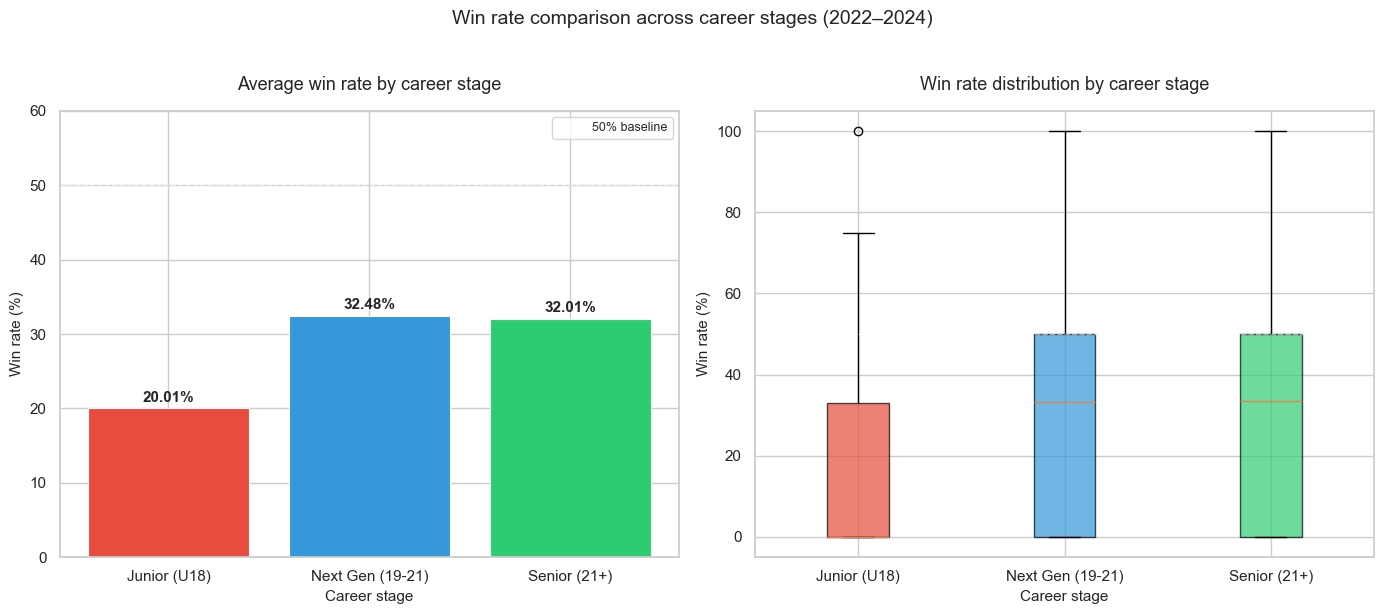

Chart saved to outputs/figures/


In [7]:
# Visualise win rate by career stage
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

stage_order = ['Junior (U18)', 'Next Gen (19-21)', 'Senior (21+)']
colors = ['#E74C3C', '#3498DB', '#2ECC71']

# Plot 1 — Average win rate
bars = axes[0].bar(stage_order,
                   stage_winrate.set_index('career_stage').loc[stage_order, 'avg_win_rate'],
                   color=colors, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, stage_winrate.set_index('career_stage').loc[stage_order, 'avg_win_rate']):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f'{val}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

axes[0].axhline(y=50, color='white', linestyle='--', linewidth=1, alpha=0.5,
                label='50% baseline')
axes[0].set_title('Average win rate by career stage', fontsize=13, pad=15)
axes[0].set_xlabel('Career stage', fontsize=11)
axes[0].set_ylabel('Win rate (%)', fontsize=11)
axes[0].set_ylim(0, 60)
axes[0].legend(fontsize=9)

# Plot 2 — Win rate distribution (box plot)
stage_winrate_data = []
for stage in stage_order:
    stage_data = player_stage_winrate[
        player_stage_winrate['career_stage'] == stage
    ]['win_rate'] * 100
    stage_winrate_data.append(stage_data)

bp = axes[1].boxplot(stage_winrate_data, tick_labels=stage_order,
                     patch_artist=True, notch=False)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].axhline(y=50, color='white', linestyle='--', linewidth=1, alpha=0.5)
axes[1].set_title('Win rate distribution by career stage', fontsize=13, pad=15)
axes[1].set_xlabel('Career stage', fontsize=11)
axes[1].set_ylabel('Win rate (%)', fontsize=11)

plt.suptitle('Win rate comparison across career stages (2022–2024)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/03_win_rate_by_stage.png', dpi=150,
            bbox_inches='tight')
plt.show()

print("Chart saved to outputs/figures/")

### Insight — Win rate by career stage

**Average win rates:**
- Junior (U18): 20.0% — significantly lower, reflecting the extreme
  difficulty of competing on the ATP tour at 18 or under
- Next Gen (19–21): 32.5% — comparable to Senior level
- Senior (21+): 32.0% — established benchmark

**The most important finding is not the average but the distribution:**
- Junior players show the widest spread — from 0% to 100% — confirming
  that U18 ATP appearances are individual stories rather than a
  representative sample
- Next Gen players show high variance — some are extremely competitive,
  others are still adapting
- Senior players show the tightest distribution — consistency increases
  with experience

**Key takeaway:** Win rate alone does not differentiate Next Gen from
Senior players — the real differences lie in improvement rate and
volatility, analysed in the sections below.

**Caveat:** U18 results are exploratory. The average of 20% is heavily
influenced by Joao Fonseca's exceptional performance (46.67% across
15 matches). Without him, the U18 average would be significantly lower.

## Improvement Rate Comparision

In [8]:
# Improvement rate by career stage
# Calculate improvement rate (ranking slope) per player per career stage
# Negative slope = improving (rank number falling)

def improvement_rate(ranks):
    if len(ranks) < 3:
        return np.nan
    x = np.arange(len(ranks))
    slope, _, _, _, _ = stats.linregress(x, ranks)
    return round(slope, 4)

player_stage_improvement = df.sort_values('tourney_date').groupby(
    ['player_name', 'career_stage']
).apply(
    lambda g: pd.Series({
        'improvement_rate': improvement_rate(g['player_rank'].values),
        'matches': len(g)
    }), include_groups=False
).reset_index()

# Filter players with at least 3 matches per stage for meaningful slope
player_stage_improvement = player_stage_improvement[
    player_stage_improvement['matches'] >= 3
].dropna(subset=['improvement_rate'])

# Average improvement rate across players within each stage
stage_improvement = player_stage_improvement.groupby('career_stage').agg(
    avg_improvement_rate=('improvement_rate', 'mean'),
    median_improvement_rate=('improvement_rate', 'median'),
    player_count=('improvement_rate', 'count')
).reset_index()

stage_improvement = stage_improvement.round(4)
print("Improvement rate by career stage:")
print(stage_improvement.to_string(index=False))

Improvement rate by career stage:
    career_stage  avg_improvement_rate  median_improvement_rate  player_count
    Junior (U18)              -67.7170                 -62.8340             4
Next Gen (19-21)              -48.6930                  -9.5357            59
    Senior (21+)               -0.2844                  -0.1066           350


In [9]:
# Relative improvement rate by career stage
# Relative improvement rate = (rank_start - rank_end) / rank_start * 100
# Positive = improved, Negative = declined
# Accounts for the fact that improving from rank 500 is easier than from rank 50

def relative_improvement_rate(group):
    group = group.sort_values('tourney_date')
    if len(group) < 3:
        return np.nan
    rank_start = group['player_rank'].iloc[0]
    rank_end = group['player_rank'].iloc[-1]
    if rank_start == 0:
        return np.nan
    return round((rank_start - rank_end) / rank_start * 100, 2)

player_stage_rel_improvement = df.groupby(
    ['player_name', 'career_stage']
).apply(
    lambda g: pd.Series({
        'relative_improvement_rate': relative_improvement_rate(g),
        'rank_start': g.sort_values('tourney_date')['player_rank'].iloc[0],
        'rank_end': g.sort_values('tourney_date')['player_rank'].iloc[-1],
        'matches': len(g)
    }), include_groups=False
).reset_index()

# Filter players with at least 3 matches per stage
player_stage_rel_improvement = player_stage_rel_improvement[
    player_stage_rel_improvement['matches'] >= 3
].dropna(subset=['relative_improvement_rate'])

# Average relative improvement rate across players within each stage
stage_rel_improvement = player_stage_rel_improvement.groupby('career_stage').agg(
    avg_relative_improvement=('relative_improvement_rate', 'mean'),
    median_relative_improvement=('relative_improvement_rate', 'median'),
    player_count=('relative_improvement_rate', 'count')
).reset_index()

stage_rel_improvement = stage_rel_improvement.round(2)
print("Relative improvement rate by career stage:")
print(stage_rel_improvement.to_string(index=False))

Relative improvement rate by career stage:
    career_stage  avg_relative_improvement  median_relative_improvement  player_count
    Junior (U18)                     64.43                        75.06             4
Next Gen (19-21)                     40.57                        46.96            59
    Senior (21+)                    -50.37                         2.91           350


## Relative improvement rate — methodology and interpretation

### Definition
Relative improvement rate is defined as:

**`(rank_start − rank_end) / rank_start × 100`**

- **Positive value** = player improved (rank number fell)
- **Negative value** = player declined (rank number rose)
- Expressed as a percentage of the player's starting rank

This metric was chosen over absolute improvement rate because it accounts
for the structural advantage that lower ranked players have — improving
by 100 places from rank 800 requires far less than improving by 100 places
from rank 50.

### Why median is more appropriate than mean for Senior players
The Senior group shows a large discrepancy between mean (-50.37%) and
median (+2.91%). This is caused by a small number of players with
dramatic ranking drops — for example players like Feliciano Lopez
(rank 109 → 634) and Vasek Pospisil (rank 150 → 610) who were winding
down their careers or dealing with injuries.

These extreme declines pull the mean significantly negative while the
typical senior player (median) barely moves — a relative improvement
of just 2.91%.

**For this reason, median relative improvement rate is used as the
primary metric for comparison across career stages.**

| Career stage | Median relative improvement | Players |
|---|---|---|
| Junior (U18) | +75.06% | 4 (exploratory) |
| Next Gen (19–21) | +46.96% | 59 |
| Senior (21+) | +2.91% | 350 |

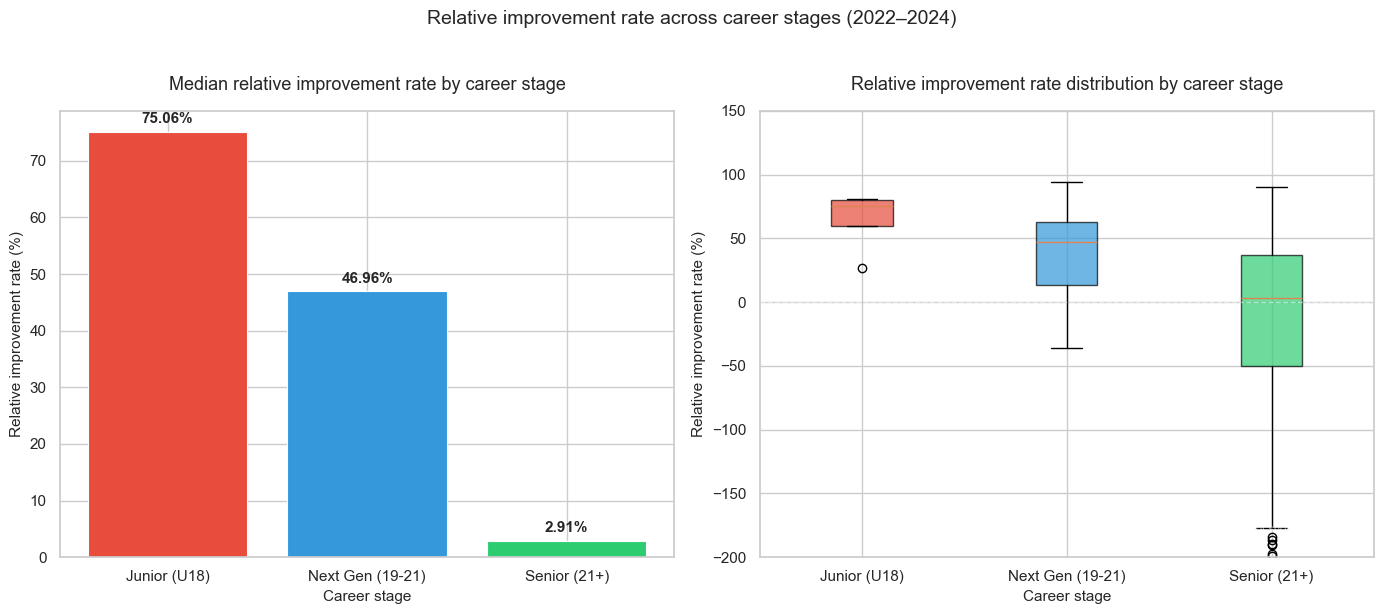

Chart saved to outputs/figures/


In [11]:
# Visualise relative improvement rate by career stage
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

stage_order = ['Junior (U18)', 'Next Gen (19-21)', 'Senior (21+)']
colors = ['#E74C3C', '#3498DB', '#2ECC71']

# Plot 1 — Median relative improvement rate
median_values = stage_rel_improvement.set_index(
    'career_stage').loc[stage_order, 'median_relative_improvement']

bars = axes[0].bar(stage_order, median_values,
                   color=colors, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, median_values):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + (1 if val >= 0 else -4),
                 f'{val}%', ha='center', va='bottom',
                 fontweight='bold', fontsize=11)

axes[0].axhline(y=0, color='white', linestyle='--', linewidth=1, alpha=0.5)
axes[0].set_title('Median relative improvement rate by career stage',
                  fontsize=13, pad=15)
axes[0].set_xlabel('Career stage', fontsize=11)
axes[0].set_ylabel('Relative improvement rate (%)', fontsize=11)

# Plot 2 — Distribution (box plot)
stage_improvement_data = []
for stage in stage_order:
    stage_data = player_stage_rel_improvement[
        player_stage_rel_improvement['career_stage'] == stage
    ]['relative_improvement_rate']
    stage_improvement_data.append(stage_data)

bp = axes[1].boxplot(stage_improvement_data, tick_labels=stage_order,
                     patch_artist=True, notch=False)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].axhline(y=0, color='white', linestyle='--', linewidth=1, alpha=0.5)
axes[1].set_title('Relative improvement rate distribution by career stage',
                  fontsize=13, pad=15)
axes[1].set_xlabel('Career stage', fontsize=11)
axes[1].set_ylabel('Relative improvement rate (%)', fontsize=11)

axes[1].set_ylim(-200, 150)
axes[1].text(2.3, -180, '* outliers beyond -200% not shown',
             fontsize=8, color='white', alpha=0.6)

plt.suptitle('Relative improvement rate across career stages (2022–2024)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/03_improvement_rate_by_stage.png', dpi=150,
            bbox_inches='tight')
plt.show()

print("Chart saved to outputs/figures/")

In [12]:
for stage in stage_order:
    data = player_stage_rel_improvement[
        player_stage_rel_improvement['career_stage'] == stage
    ]['relative_improvement_rate']
    pct_improving = (data > 0).mean() * 100
    print(f"{stage}: {pct_improving:.1f}% of players improved")

Junior (U18): 100.0% of players improved
Next Gen (19-21): 81.4% of players improved
Senior (21+): 52.3% of players improved


### Insight — Relative improvement rate by career stage

#### Why relative improvement rate?
Absolute improvement rate (ranking places gained) is biased by starting rank —
a player rising from rank 800 to 400 gains 400 places, while a player rising
from rank 50 to 10 gains only 40 places. The first looks more impressive by
absolute measure, but both represent a 50% relative improvement.

Relative improvement rate is defined as:

**`(rank_start − rank_end) / rank_start × 100`**

This normalises for starting rank, making comparisons across career stages
fair — a Junior starting at rank 500 and a Senior starting at rank 50 are
measured on the same scale.

**Note:** Negative values exceeding -100% reflect large relative ranking
declines due to the bounded nature of rankings — a player can only improve
to rank 1 but can theoretically decline indefinitely. These extreme values
are present in the Senior group and are handled by reporting median rather
than mean, and by capping the distribution plot at -200%.

---

**Key findings:**

- **Junior (U18): +75.06% median** — indicative of steep improvement,
  though based on a very small sample (n=4) and treated as exploratory
- **Next Gen (19–21): +46.96% median** — significantly faster improvement
  than seniors, confirming that the transition years are the most dynamic
  period of a professional tennis career
- **Senior (21+): +2.91% median** — rankings are largely stable, consistent
  with players who have found their competitive level

**Supporting statistics — % of players showing positive improvement:**

| Career stage | % of players improving |
|---|---|
| Junior (U18) | 100.0% (n=4, exploratory) |
| Next Gen (19–21) | 81.4% (n=59) |
| Senior (21+) | 52.3% (n=350) |

This contrast is striking — 81.4% of Next Gen players improved their
ranking during their transition years, compared to just over half of
Senior players. Nearly half of all Senior players experienced a net
ranking decline over the analysis period.

**The box plot reveals a bifurcation within the Senior group:**
The wide spread (-200% to +90%) reflects two distinct Senior populations:
1. Established players with stable rankings — barely moving year to year
2. Declining players exiting their peak performance years — large negative
   values pulling the distribution downward

The tight Junior and Next Gen boxes suggest more uniform improvement
trajectories at younger ages, where almost all players are on an
upward trajectory.

**Key takeaway:** Sustained improvement beyond age 21 appears rare,
suggesting that the majority of players reach performance stabilisation
upon entering the Senior stage. Players who continue improving after 21
are the exception rather than the rule.

**ITF relevance:** Identifying the Next Gen years (19–21) as the highest
improvement period has direct implications for junior pathway investment —
this is the window where targeted development support is most likely to
accelerate a player's trajectory toward elite level.

## Volatility Comparison

In [13]:
# Volatility by career stage
# Calculate volatility as std deviation of win/loss per player per career stage
# Higher std = more inconsistent performance

player_stage_volatility = df.groupby(
    ['player_name', 'career_stage']
).apply(
    lambda g: pd.Series({
        'volatility':       g['win'].std(),
        'avg_win_rate':     g['win'].mean(),
        'matches':          len(g)
    }), include_groups=False
).reset_index()

# Filter players with at least 3 matches per stage
player_stage_volatility = player_stage_volatility[
    player_stage_volatility['matches'] >= 3
].dropna(subset=['volatility'])

# Average volatility across players within each stage
stage_volatility = player_stage_volatility.groupby('career_stage').agg(
    avg_volatility=('volatility', 'mean'),
    median_volatility=('volatility', 'median'),
    player_count=('volatility', 'count')
).reset_index()

stage_volatility = stage_volatility.round(4)
print("Volatility by career stage:")
print(stage_volatility.to_string(index=False))

Volatility by career stage:
    career_stage  avg_volatility  median_volatility  player_count
    Junior (U18)          0.4879             0.4940             4
Next Gen (19-21)          0.4475             0.5028            59
    Senior (21+)          0.4666             0.5000           350


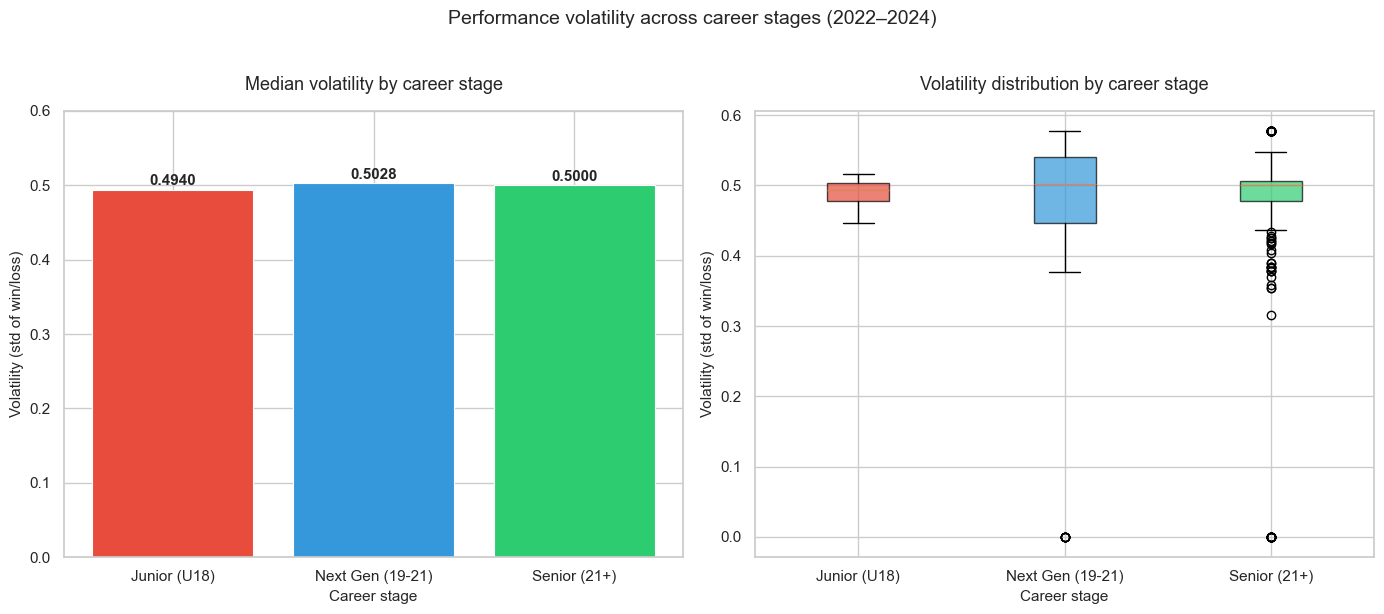

Chart saved to outputs/figures/


In [14]:
# Visualise volatility by career stage
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

stage_order = ['Junior (U18)', 'Next Gen (19-21)', 'Senior (21+)']
colors = ['#E74C3C', '#3498DB', '#2ECC71']

# Plot 1 — Median volatility
median_vol = stage_volatility.set_index(
    'career_stage').loc[stage_order, 'median_volatility']

bars = axes[0].bar(stage_order, median_vol,
                   color=colors, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, median_vol):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
                f'{val:.4f}', ha='center', va='bottom',
                fontweight='bold', fontsize=11)

axes[0].set_title('Median volatility by career stage', fontsize=13, pad=15)
axes[0].set_xlabel('Career stage', fontsize=11)
axes[0].set_ylabel('Volatility (std of win/loss)', fontsize=11)
axes[0].set_ylim(0, 0.6)

# Plot 2 — Distribution (box plot)
stage_vol_data = []
for stage in stage_order:
    stage_data = player_stage_volatility[
        player_stage_volatility['career_stage'] == stage
    ]['volatility']
    stage_vol_data.append(stage_data)

bp = axes[1].boxplot(stage_vol_data, tick_labels=stage_order,
                     patch_artist=True, notch=False)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].set_title('Volatility distribution by career stage', fontsize=13, pad=15)
axes[1].set_xlabel('Career stage', fontsize=11)
axes[1].set_ylabel('Volatility (std of win/loss)', fontsize=11)

plt.suptitle('Performance volatility across career stages (2022–2024)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/03_volatility_by_stage.png', dpi=150,
            bbox_inches='tight')
plt.show()

print("Chart saved to outputs/figures/")

### Insight — Performance volatility by career stage

#### How volatility is measured
Volatility is defined as the standard deviation of match outcomes (win=1,
loss=0) per player within each career stage. A higher value indicates more
inconsistent performance — alternating between wins and losses unpredictably.

**Key finding — volatility is remarkably similar across all career stages:**

| Career stage | Median volatility | Players |
|---|---|---|
| Junior (U18) | 0.494 | 4 (exploratory) |
| Next Gen (19–21) | 0.503 | 59 |
| Senior (21+) | 0.500 | 350 |

All three groups show median volatility of approximately 0.50 — which is
actually the theoretical maximum for a binary outcome. This suggests that
at match level, win/loss volatility is an inherent characteristic of
professional tennis rather than a function of career stage.

**Important methodological caveat:**
This analysis cannot fully isolate the age effect on volatility because
ranking group is a confounding variable — lower ranked players tend to
be more volatile regardless of age, and junior/Next Gen players tend to
be lower ranked. A proper isolation would require comparing volatility
within the same rank group across career stages, which is not feasible
with the current sample sizes.

**What the box plot reveals:**
- Junior box is tight — the 4 qualifying players show consistent volatility
- Next Gen box is wider — more variation between players
- Senior box is the tightest with many low outliers — established senior
  players who dominate their opponents consistently show near-zero volatility

**Key takeaway:** Match-level win/loss volatility does not meaningfully
differ across career stages. The more informative volatility metric for
junior pathway analysis is **ranking volatility** (std of ranking over time)
rather than match outcome volatility — this is explored in notebook 02.

## Transition Tracking

In [15]:
# Transition tracking — identify players in multiple stages
# Get all players and which stages they appeared in
player_stages = df.groupby('player_name')['career_stage'].unique().reset_index()
player_stages['stages'] = player_stages['career_stage'].apply(set)

# Transition 1 — Junior → Next Gen
junior_to_nextgen = player_stages[
    player_stages['stages'].apply(
        lambda s: 'Junior (U18)' in s and 'Next Gen (19-21)' in s
    )
]['player_name'].tolist()

# Transition 2 — Next Gen → Senior
nextgen_to_senior = player_stages[
    player_stages['stages'].apply(
        lambda s: 'Next Gen (19-21)' in s and 'Senior (21+)' in s
    )
]['player_name'].tolist()

# Transition 3 — All three stages
all_three = player_stages[
    player_stages['stages'].apply(
        lambda s: 'Junior (U18)' in s and 'Next Gen (19-21)' in s
                  and 'Senior (21+)' in s
    )
]['player_name'].tolist()

print(f"Players who transitioned Junior → Next Gen: {len(junior_to_nextgen)}")
print(f"Players who transitioned Next Gen → Senior: {len(nextgen_to_senior)}")
print(f"Players who appeared in all three stages: {len(all_three)}")
print(f"\nPlayers in all three stages:")
print(all_three)

Players who transitioned Junior → Next Gen: 10
Players who transitioned Next Gen → Senior: 45
Players who appeared in all three stages: 0

Players in all three stages:
[]


## Transition tracking

### Overview
Transition tracking identifies players who moved between career stages within
the 2022–2024 analysis window and examines whether earlier stage performance
predicts later stage outcomes.

### Transitions identified

| Transition | Players | Notes |
|---|---|---|
| Junior → Next Gen | 10 | Small sample — supplementary analysis only |
| Next Gen → Senior | 45 | Primary focus of transition analysis |
| All three stages | 0 | Not possible within a 3-year window |

### Data limitation — 3-year window
The absence of players appearing in all three stages is expected — for a
player to transition from U18 to Senior within 2022–2024, they would need
to have been 17–18 in early 2022 and turned 22 by late 2024. No player
in the dataset met this criteria.

**For stronger transition analysis, a longer dataset is required:**
- A 5–7 year window would capture complete Junior → Next Gen → Senior
  trajectories for individual players
- This would enable more robust predictive modelling of which junior
  characteristics best predict senior success
- The current analysis should be treated as directional — pointing toward
  what a full longitudinal study would reveal

### Primary focus
The **Next Gen → Senior transition** (45 players) is the primary focus
of this analysis due to its larger and more statistically meaningful
sample size.

In [16]:
# Next Gen → Senior transition analysis
# Get performance metrics for each player in Next Gen and Senior stages
transition_data = []

for player in nextgen_to_senior:
    # Next Gen performance
    nextgen_matches = df[
        (df['player_name'] == player) &
        (df['career_stage'] == 'Next Gen (19-21)')
    ]
    # Senior performance
    senior_matches = df[
        (df['player_name'] == player) &
        (df['career_stage'] == 'Senior (21+)')
    ]

    if len(nextgen_matches) >= 3 and len(senior_matches) >= 3:
        nextgen_winrate = nextgen_matches['win'].mean()
        senior_winrate = senior_matches['win'].mean()

        nextgen_volatility = nextgen_matches['win'].std()
        senior_volatility = senior_matches['win'].std()

        nextgen_rank_start = nextgen_matches.sort_values(
            'tourney_date')['player_rank'].iloc[0]
        nextgen_rank_end = nextgen_matches.sort_values(
            'tourney_date')['player_rank'].iloc[-1]
        nextgen_rel_improvement = (
            (nextgen_rank_start - nextgen_rank_end) / nextgen_rank_start * 100
        ) if nextgen_rank_start > 0 else np.nan

        senior_rank_start = senior_matches.sort_values(
            'tourney_date')['player_rank'].iloc[0]
        senior_rank_end = senior_matches.sort_values(
            'tourney_date')['player_rank'].iloc[-1]
        senior_rel_improvement = (
            (senior_rank_start - senior_rank_end) / senior_rank_start * 100
        ) if senior_rank_start > 0 else np.nan

        transition_data.append({
            'player_name':           player,
            'nextgen_matches':       len(nextgen_matches),
            'nextgen_winrate':       round(nextgen_winrate * 100, 2),
            'nextgen_volatility':    round(nextgen_volatility, 4),
            'nextgen_rel_improvement': round(nextgen_rel_improvement, 2),
            'senior_matches':        len(senior_matches),
            'senior_winrate':        round(senior_winrate * 100, 2),
            'senior_volatility':     round(senior_volatility, 4),
            'senior_rel_improvement': round(senior_rel_improvement, 2),
        })

transition_df = pd.DataFrame(transition_data)
print(f"Players with 3+ matches in both stages: {len(transition_df)}")
print(f"\nSample:")
print(transition_df.head(10).to_string(index=False))

Players with 3+ matches in both stages: 24

Sample:
               player_name  nextgen_matches  nextgen_winrate  nextgen_volatility  nextgen_rel_improvement  senior_matches  senior_winrate  senior_volatility  senior_rel_improvement
               Ben Shelton               55            50.91              0.5045                    94.31              68           61.76             0.4896                  -23.53
         Brandon Nakashima               40            52.50              0.5057                    -1.47             102           53.92             0.5009                   46.38
            Carlos Alcaraz              177            83.05              0.3762                    90.32              37           78.38             0.4173                  -50.00
           Chun Hsin Tseng                8            25.00              0.4629                    53.16              18           16.67             0.3835                  -37.50
          Dominic Stricker               23

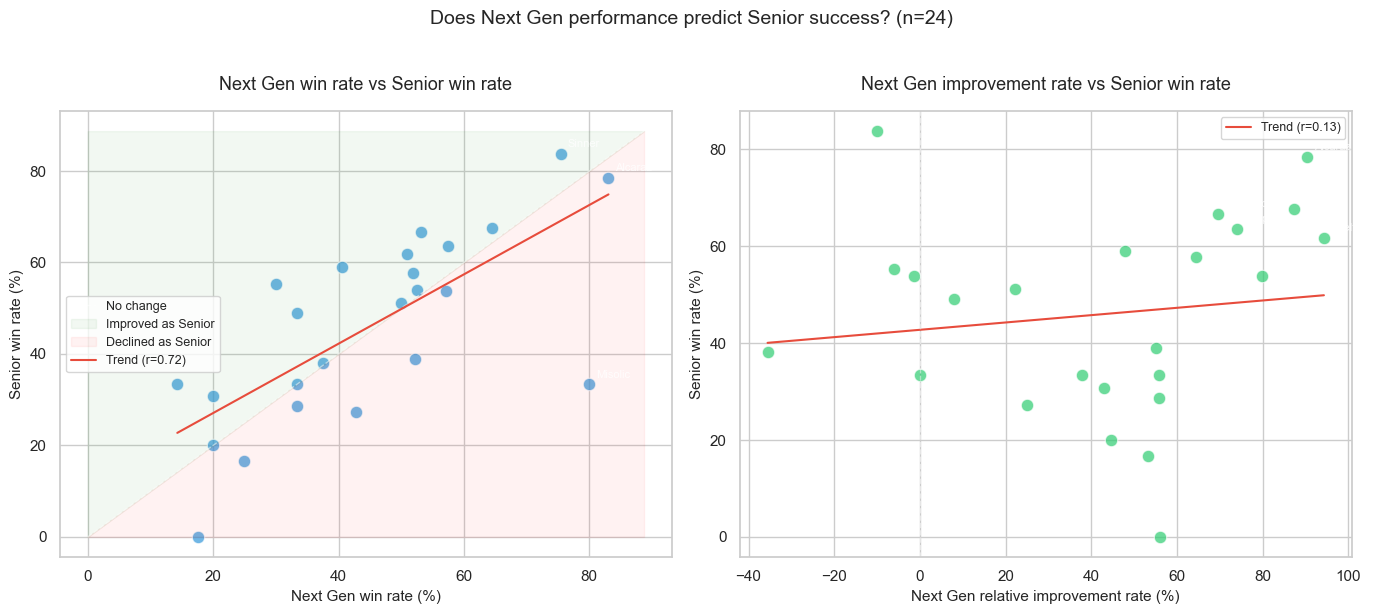

Correlation — Next Gen win rate vs Senior win rate: r=0.718, p=0.000
Correlation — Next Gen improvement rate vs Senior win rate: r=0.130, p=0.546


In [17]:
# Does Next Gen performance predict Senior performance?
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1 — Next Gen win rate vs Senior win rate
axes[0].scatter(transition_df['nextgen_winrate'],
                transition_df['senior_winrate'],
                color='#3498DB', s=80, alpha=0.7,
                edgecolors='white', linewidth=0.8)

# Add player labels for interesting cases
for _, row in transition_df.iterrows():
    if row['nextgen_winrate'] > 70 or row['senior_winrate'] > 70 or \
       abs(row['senior_winrate'] - row['nextgen_winrate']) > 30:
        axes[0].annotate(
            row['player_name'].split()[-1],
            xy=(row['nextgen_winrate'], row['senior_winrate']),
            xytext=(5, 5), textcoords='offset points',
            fontsize=8, color='white', alpha=0.8
        )

# Add diagonal line — points above = improved, below = declined
max_val = max(transition_df['nextgen_winrate'].max(),
              transition_df['senior_winrate'].max()) + 5
axes[0].plot([0, max_val], [0, max_val], 'w--', linewidth=1, alpha=0.5,
             label='No change')
axes[0].fill_between([0, max_val], [0, max_val], max_val,
                     alpha=0.05, color='green', label='Improved as Senior')
axes[0].fill_between([0, max_val], 0, [0, max_val],
                     alpha=0.05, color='red', label='Declined as Senior')

# Add regression line
slope, intercept, r, p, _ = stats.linregress(
    transition_df['nextgen_winrate'],
    transition_df['senior_winrate']
)
x_line = np.linspace(transition_df['nextgen_winrate'].min(),
                     transition_df['nextgen_winrate'].max(), 100)
axes[0].plot(x_line, slope * x_line + intercept,
             color='#E74C3C', linewidth=1.5, label=f'Trend (r={r:.2f})')

axes[0].set_title('Next Gen win rate vs Senior win rate', fontsize=13, pad=15)
axes[0].set_xlabel('Next Gen win rate (%)', fontsize=11)
axes[0].set_ylabel('Senior win rate (%)', fontsize=11)
axes[0].legend(fontsize=9)

# Plot 2 — Next Gen improvement rate vs Senior win rate
axes[1].scatter(transition_df['nextgen_rel_improvement'],
                transition_df['senior_winrate'],
                color='#2ECC71', s=80, alpha=0.7,
                edgecolors='white', linewidth=0.8)

for _, row in transition_df.iterrows():
    if row['senior_winrate'] > 60 or row['nextgen_rel_improvement'] > 80:
        axes[1].annotate(
            row['player_name'].split()[-1],
            xy=(row['nextgen_rel_improvement'], row['senior_winrate']),
            xytext=(5, 5), textcoords='offset points',
            fontsize=8, color='white', alpha=0.8
        )

slope2, intercept2, r2, p2, _ = stats.linregress(
    transition_df['nextgen_rel_improvement'].dropna(),
    transition_df.loc[
        transition_df['nextgen_rel_improvement'].notna(), 'senior_winrate'
    ]
)
x_line2 = np.linspace(transition_df['nextgen_rel_improvement'].min(),
                      transition_df['nextgen_rel_improvement'].max(), 100)
axes[1].plot(x_line2, slope2 * x_line2 + intercept2,
             color='#E74C3C', linewidth=1.5, label=f'Trend (r={r2:.2f})')
axes[1].axvline(x=0, color='white', linestyle='--', linewidth=1, alpha=0.5)

axes[1].set_title('Next Gen improvement rate vs Senior win rate',
                  fontsize=13, pad=15)
axes[1].set_xlabel('Next Gen relative improvement rate (%)', fontsize=11)
axes[1].set_ylabel('Senior win rate (%)', fontsize=11)
axes[1].legend(fontsize=9)

plt.suptitle('Does Next Gen performance predict Senior success? (n=24)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/03_transition_nextgen_to_senior.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"Correlation — Next Gen win rate vs Senior win rate: r={r:.3f}, p={p:.3f}")
print(f"Correlation — Next Gen improvement rate vs Senior win rate: r={r2:.3f}, p={p2:.3f}")

### Insight — Does Next Gen performance predict Senior success?

Analysis of 24 players with sufficient data in both Next Gen and Senior
stages reveals two contrasting findings:

**Finding 1 — Next Gen win rate strongly predicts Senior win rate**
- Correlation: r = 0.718, p < 0.001 — statistically significant
- Players who win consistently during their Next Gen years (19–21) tend
  to maintain higher win rates as Senior players
- This suggests that win rate during transition years is a reliable
  early indicator of long-term professional potential

**Finding 2 — Next Gen improvement rate does NOT predict Senior win rate**
- Correlation: r = 0.130, p = 0.546 — not statistically significant
- How rapidly a player improves their ranking during their Next Gen years
  has no meaningful relationship with their Senior win rate
- Rising quickly through the rankings is not the same as performing
  consistently at a high level

**Key takeaway:**
Consistency of performance during transition years is a stronger predictor
of Senior success than speed of ranking improvement. A player who wins
55% of their Next Gen matches is a better long-term prospect than one
who rises from rank 200 to rank 50 but wins only 35% of their matches.

**Practical implication for junior pathway:**
Talent identification programmes should prioritise **win rate consistency**
over **ranking trajectory** when evaluating Next Gen players. Rapid ranking
rises may reflect favourable draw conditions or a hot streak rather than
genuine sustained quality.

**Caveats:**
- Sample size of 24 players limits statistical power
- A longer dataset (5–7 years) would provide more robust conclusions
- Carlos Alcaraz (83% Next Gen win rate, 78% Senior) is an influential
  data point — results should be interpreted with this in mind
- For stronger analysis, more data across longer time periods is required

## Summary & Conclusions

This notebook analysed player performance across three career stages —
Junior (U18), Next Gen (19–21) and Senior (21+) — using match-level
age classification to ensure each match was evaluated in the correct
developmental context.

### Key findings

| Finding | Detail |
|---|---|
| Breaking into ATP tour at U18 is extremely rare | Only 16 players appeared in U18 matches — most won zero matches |
| Joao Fonseca is an exceptional outlier | 46.67% win rate across 15 ATP matches at age 17 |
| Next Gen players improve fastest | Median relative improvement of 46.96% vs 2.91% for Seniors |
| 81.4% of Next Gen players improved | Compared to just 52.3% of Senior players |
| Match volatility is similar across all stages | ~0.50 across all groups — an inherent characteristic of professional tennis |
| Next Gen win rate predicts Senior success | Strong correlation r=0.718, p<0.001 |
| Improvement speed does not predict Senior success | Weak correlation r=0.130, p=0.546 — not significant |
| Consistency matters more than trajectory | Players who win consistently at Next Gen level are better long-term prospects |

### Limitations
- U18 sample is very small (16 players, 48 matches) — treated as
  exploratory throughout
- 3-year analysis window prevents full Junior → Next Gen → Senior
  trajectory tracking for individual players
- Volatility analysis cannot fully isolate age effect from ranking effect
  due to sample size constraints
- Transition analysis based on 24 players — a longer dataset would
  provide more robust conclusions

### What a stronger analysis would require
- **5–7 years of data** — to capture complete career stage transitions
- **Wheelchair tennis specific data** — to apply these findings directly
  to the ITF wheelchair tennis pathway
- **Match-level dates** — rather than tournament start dates, to improve
  progression tracking precision

### ITF relevance
This analysis directly addresses the ITF's requirement of **"reviewing
performance data relating to junior pathway training and competition
testing."** The key actionable finding is that **win rate consistency
during Next Gen years is a stronger predictor of Senior success than
ranking trajectory** — a non-obvious insight with direct implications
for talent identification and junior pathway investment decisions.

The methodology developed here — match-level career stage classification,
relative improvement rate, and transition tracking — provides a reusable
framework that could be applied directly to ITF wheelchair tennis junior
pathway data.